# 03 -- Merge & Explore

Joins all processed data into one dataset, explores correlations and data quality.

**Output:** `data/processed/merged_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
sys.path.insert(0, os.path.join(PROJECT_DIR, 'shared'))
from macro_utils import merge_frequencies_to_daily, add_forward_return_target

## 1. Load All Processed Data

In [2]:
def load_if_exists(name, parse_dates=[0], index_col=0):
    path = os.path.join(PROCESSED_DIR, name)
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=parse_dates, index_col=index_col)
        print(f"{name}: {df.shape}")
        return df
    print(f"{name}: NOT FOUND")
    return pd.DataFrame()

sp500 = load_if_exists('sp500_index.csv')
macros_d = load_if_exists('macros_daily.csv')
macros_m = load_if_exists('macros_monthly.csv')
macros_q = load_if_exists('macros_quarterly.csv')
commodities = load_if_exists('commodities_daily.csv')
constituents = load_if_exists('constituent_stats.csv')
sp_ratios = load_if_exists('sp_ratios_monthly.csv')

sp500_index.csv: (8817, 38)
macros_daily.csv: (22425, 36)
macros_monthly.csv: (3681, 60)
macros_quarterly.csv: (569, 30)
commodities_daily.csv: (6167, 78)
constituent_stats.csv: (6289, 33)
sp_ratios_monthly.csv: (660, 69)


## 2. Merge

S&P 500 index = spine (daily business days). Daily sources join directly. Monthly/quarterly forward-fill upsampled.

In [3]:
merged = sp500.copy()

for df, label in [(macros_d, 'macro'), (commodities, 'comm'), (constituents, 'const')]:
    if not df.empty:
        merged = merged.join(df, how='left', rsuffix=f'_{label}')

# Combine monthly sources
monthly_combined = pd.DataFrame()
for df in [macros_m, sp_ratios]:
    if not df.empty:
        monthly_combined = monthly_combined.join(df, how='outer') if not monthly_combined.empty else df

merged = merge_frequencies_to_daily(merged, monthly_df=monthly_combined, quarterly_df=macros_q)
merged = merged.ffill()

# Drop columns with >50% NaN
bad = merged.isna().mean()
drop_cols = bad[bad > 0.5].index.tolist()
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns (>50% NaN)")
    merged = merged.drop(columns=drop_cols)

merged = merged.dropna()
print(f"\nFinal: {merged.shape}, {merged.index[0].date()} to {merged.index[-1].date()}")

merged.to_csv(os.path.join(PROCESSED_DIR, 'merged_dataset.csv'))
print("Saved merged_dataset.csv")

Dropping 132 columns (>50% NaN)

Final: (27374, 212), 1993-01-18 to 2024-12-31
Saved merged_dataset.csv


## 3. Exploration — Honest Signal Diagnostic

Goal: determine whether any feature has a genuine predictive relationship with forward S&P 500 returns, after correcting for the two most common failure modes:

1. **Lookahead leakage** — fixed in `02_Processing.ipynb` by applying a publication lag to financial ratios. Macro/commodity series already had appropriate lags.
2. **Spurious trend-on-trend correlation** — trending level features correlate mechanically with a trending market. The pipeline creates change/z-score versions of each series via `add_alpha_columns`; we use only those here.

Tests run below:
- **A.** Multi-horizon correlation (30/60/90d) — genuine signal should persist across horizons
- **B.** Rolling 5-year correlation stability — genuine signal should be relatively stable across decades
- **C.** Quintile-spread test — top-quintile vs bottom-quintile forward return on top survivors

In [4]:
# Classify features: changes/z-scores vs raw levels
# Rule: a feature is a change/ratio/z-score if its name contains one of these patterns
CHANGE_PATTERNS = [
    '_d1', '_w1', '_m1', '_q1', '_y1',       # alpha columns (get_alpha changes)
    'pct_from_',                              # rolling distance from max/min (ratio)
    'momentum_', 'ma_return_', 'realized_vol_', 'return_trend_',  # add_return_features
    'herfindahl_', 'skewness', '_ma',         # constituent stats
    'days_since_', 'last_peak_alpha', 'last_trough_alpha',  # pico features
    'outlier', 'pctile',                      # expanding outlier/percentile flags
    'turnover', 'avg_ret',                    # daily aggregates (returns, not levels)
    'sprtrn',                                 # sp500 daily return
]

def is_change_feature(col):
    return any(p in col for p in CHANGE_PATTERNS)

all_feats = [c for c in merged.columns if not c.startswith('target_')]
change_feats = [c for c in all_feats if is_change_feature(c)]
level_feats = [c for c in all_feats if not is_change_feature(c)]

print(f"Total features: {len(all_feats)}")
print(f"  Change/z-score features: {len(change_feats)}")
print(f"  Level features: {len(level_feats)}")

# Build multi-horizon targets: 30d, 60d, 90d
HORIZONS = [30, 60, 90]
df = merged.copy()
for h in HORIZONS:
    df = add_forward_return_target(df, 'spindx', horizon=h)

print(f"\nTargets built: {['target_return_' + str(h) + 'd' for h in HORIZONS]}")

Total features: 212
  Change/z-score features: 112
  Level features: 100

Targets built: ['target_return_30d', 'target_return_60d', 'target_return_90d']


In [5]:
# ============================================================
# TEST A: Multi-horizon correlation (changes/z-scores only)
# ============================================================
# Features that truly predict forward returns should show similar
# correlation magnitude at 30, 60, and 90 day horizons. A feature
# that only works at one specific horizon is likely spurious.

corr_by_horizon = {}
for h in HORIZONS:
    target_col = f'target_return_{h}d'
    corrs = df[change_feats].corrwith(df[target_col]).dropna().abs()
    corr_by_horizon[f'{h}d'] = corrs

corr_table = pd.DataFrame(corr_by_horizon)
corr_table['mean_abs_corr'] = corr_table.mean(axis=1)
corr_table['min_abs_corr'] = corr_table.min(axis=1)   # worst of the 3 horizons
corr_table = corr_table.sort_values('mean_abs_corr', ascending=False)

print("Top 20 change/z-score features by mean |corr| across 30/60/90d horizons:")
print("(min_abs_corr = worst horizon — want this high for a 'stable across horizons' feature)")
print()
print(corr_table.head(20).round(4).to_string())

Top 20 change/z-score features by mean |corr| across 30/60/90d horizons:
(min_abs_corr = worst horizon — want this high for a 'stable across horizons' feature)

                                                      30d     60d     90d  mean_abs_corr  min_abs_corr
m1_money_supply_y1                                 0.1305  0.1863  0.2171         0.1779        0.1305
m1_money_supply_velocity_y1                        0.1183  0.1655  0.1991         0.1610        0.1183
deuda_y1                                           0.1073  0.1601  0.2070         0.1581        0.1073
commodities_y1                                     0.1037  0.1526  0.1881         0.1481        0.1037
m1_money_supply_velocity_q1                        0.1009  0.1398  0.1620         0.1342        0.1009
rolling_max_60                                     0.0973  0.1367  0.1637         0.1326        0.0973
rolling_max_126                                    0.0949  0.1349  0.1621         0.1306        0.0949
rolling_max_252

In [6]:
# ============================================================
# REFERENCE: Level features (shown for contrast, NOT used as signal)
# ============================================================
# These correlations are partly mechanical (trending feature vs
# trending market). Shown so we can see the gap vs changes/z-scores.

level_corrs = df[level_feats].corrwith(df['target_return_60d']).dropna().abs().sort_values(ascending=False)
print("Top 10 LEVEL features at 60d (reference only — likely inflated by trend-on-trend):")
print(level_corrs.head(10).round(4).to_string())

if len(corr_table) > 0:
    top_change = corr_table.head(1).iloc[0]['60d']
    top_level = level_corrs.head(1).iloc[0] if len(level_corrs) > 0 else float('nan')
    print(f"\nTop change-feature |corr| at 60d: {top_change:.4f}")
    print(f"Top level-feature |corr| at 60d:  {top_level:.4f}")
    print(f"Gap: {top_level - top_change:+.4f}  (positive gap suggests trend-on-trend inflation)")

Top 10 LEVEL features at 60d (reference only — likely inflated by trend-on-trend):
federal_surplus_deficit                           0.2274
curr_debt                                         0.2163
short_debt                                        0.2163
deuda                                             0.2154
government_spending_total                         0.2123
m1_money_supply_velocity                          0.1990
electricity                                       0.1916
nonfinance_corporate_quarter_financial_reports    0.1916
government_spending_interest_payments             0.1863
debt_assets                                       0.1717

Top change-feature |corr| at 60d: 0.1863
Top level-feature |corr| at 60d:  0.2274
Gap: +0.0411  (positive gap suggests trend-on-trend inflation)


In [9]:
# ============================================================
# TEST B: Rolling 5-year correlation stability
# ============================================================
# A genuine signal should have reasonably stable correlation across
# decades. Features that swing from +0.3 to -0.2 over time are
# regime-dependent at best, spurious at worst.

# Pick top 10 change features by mean_abs_corr as candidates
# ============================================================
# TEST B: Rolling 5-year correlation stability
# ============================================================
candidates = corr_table.head(15).index.tolist()  # pull a few more to survive dedup

target_col = 'target_return_60d'
window_days = 252 * 5

rolling_corrs = pd.DataFrame(index=df.index)
for feat in candidates:
    rolling_corrs[feat] = df[feat].rolling(window_days).corr(df[target_col])

# Build stability table, then clean
stability = pd.DataFrame({
    'full_sample_corr':  corr_table.loc[candidates, '60d'],
    'rolling_mean_corr': rolling_corrs.mean().abs(),
    'rolling_std_corr':  rolling_corrs.std(),
    'rolling_min_corr':  rolling_corrs.min(),
    'rolling_max_corr':  rolling_corrs.max(),
    'frac_same_sign':    (rolling_corrs.apply(lambda s: (s > 0).mean() if s.mean() > 0 else (s < 0).mean())),
})
stability['stability_score'] = stability['rolling_mean_corr'] / (stability['rolling_std_corr'] + 1e-6)

# Drop rows with NaN/inf (features where rolling corr couldn't be computed reliably)
stability = stability.replace([np.inf, -np.inf], np.nan).dropna()

# Deduplicate near-identical features — keep the best stability_score within each family.
# Two features are "same family" if they share a common prefix (strip _d1/_w1/_m1/_q1/_y1/_60/_126/_252 suffixes).
import re
def feat_family(name):
    return re.sub(r'(_d1|_w1|_m1|_q1|_y1|_\d+)$', '', name)

stability['family'] = stability.index.map(feat_family)
stability = (stability
             .sort_values('stability_score', ascending=False)
             .groupby('family', as_index=False, sort=False).head(1)
             .drop(columns='family'))

print("Rolling 5y |corr| stability (NaN/inf dropped, 1 feature per family):")
print("(stability_score = rolling_mean / rolling_std — higher = more stable)")
print("(frac_same_sign  = fraction of rolling windows where sign matches full-sample sign)")
print()
print(stability.round(4).to_string())

Rolling 5y |corr| stability (NaN/inf dropped, 1 feature per family):
(stability_score = rolling_mean / rolling_std — higher = more stable)
(frac_same_sign  = fraction of rolling windows where sign matches full-sample sign)

                                                   full_sample_corr  rolling_mean_corr  rolling_std_corr  rolling_min_corr  rolling_max_corr  frac_same_sign  stability_score
rolling_max_60                                               0.1367             0.1529            0.1835           -0.5857            0.5877          0.7567           0.8332
vix_y1                                                       0.1086             0.1190            0.1769           -0.3572            0.5168          0.7193           0.6730
m1_money_supply_velocity_q1                                  0.1398             0.0899            0.2233           -0.6035            0.6321          0.6237           0.4025
government_spending_interest_payments_y1                     0.1199             

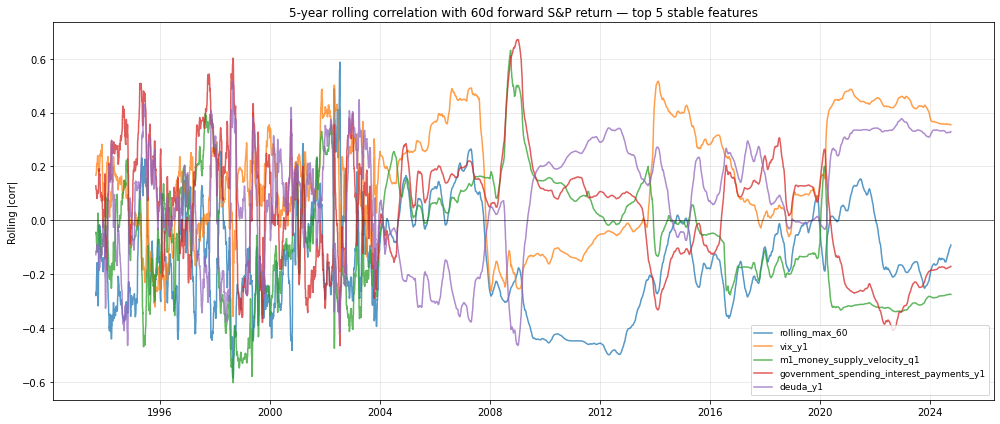

In [10]:
# Visualize rolling correlations for top 5 stable features
top_stable = stability.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for feat in top_stable:
    ax.plot(rolling_corrs.index.to_numpy(), rolling_corrs[feat].to_numpy(), label=feat, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('5-year rolling correlation with 60d forward S&P return — top 5 stable features')
ax.set_ylabel('Rolling |corr|')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# TEST C: Quintile-spread test on top 3 stable features at 60d
# ============================================================
# For a genuinely predictive feature, the top-quintile observations
# should have a meaningfully higher forward 60d return than the
# bottom-quintile observations. Sample monthly (avoid autocorrelation
# inflation from overlapping daily windows).

target_col = 'target_return_60d'
top_features = stability.head(3).index.tolist()

# Monthly sample: one observation per calendar month (last business day)
monthly_df = df.resample('M').last().dropna(subset=[target_col])
print(f"Monthly sample size: {len(monthly_df)} months\n")

results = []
for feat in top_features:
    sub = monthly_df[[feat, target_col]].dropna()
    if len(sub) < 60:  # need 5+ years of monthly data
        continue
    # Rank into 5 quintiles
    sub = sub.copy()
    sub['quintile'] = pd.qcut(sub[feat], 5, labels=False, duplicates='drop')
    by_q = sub.groupby('quintile')[target_col].agg(['mean', 'std', 'count'])
    # Spread: Q4 (top) minus Q0 (bottom)
    if 4 in by_q.index and 0 in by_q.index:
        spread_mean = by_q.loc[4, 'mean'] - by_q.loc[0, 'mean']
        # t-stat for difference in means
        n4, n0 = by_q.loc[4, 'count'], by_q.loc[0, 'count']
        s4, s0 = by_q.loc[4, 'std'], by_q.loc[0, 'std']
        se = np.sqrt(s4**2 / n4 + s0**2 / n0)
        t_stat = spread_mean / se if se > 0 else np.nan
        results.append({
            'feature': feat,
            'Q0 (bottom)': by_q.loc[0, 'mean'],
            'Q4 (top)': by_q.loc[4, 'mean'],
            'spread (Q4-Q0)': spread_mean,
            't_stat': t_stat,
            'n_per_q': int((n4 + n0) / 2),
        })

if results:
    res_df = pd.DataFrame(results)
    print("Quintile-spread test — top 3 stable features, 60d forward return:")
    print("(|t_stat| > 2 ≈ significant at 5% level)")
    print()
    print(res_df.round(4).to_string(index=False))

    print("\n" + "=" * 60)
    print("INTERPRETATION:")
    print("- Positive spread with |t_stat| > 2 → real signal candidate")
    print("- Small spread or |t_stat| < 1 → no reliable edge")
    print("- Monthly sample avoids the autocorrelation inflation of daily overlapping windows")
else:
    print("No features had enough monthly samples for the quintile test.")

Monthly sample size: 382 months

Quintile-spread test — top 3 stable features, 60d forward return:
(|t_stat| > 2 ≈ significant at 5% level)

                    feature  Q0 (bottom)  Q4 (top)  spread (Q4-Q0)  t_stat  n_per_q
             rolling_max_60       0.0147    0.0278          0.0130  1.2896       77
                     vix_y1       0.0175    0.0199          0.0024  0.2107       77
m1_money_supply_velocity_q1       0.0240    0.0190         -0.0051 -0.4093       76

INTERPRETATION:
- Positive spread with |t_stat| > 2 → real signal candidate
- Small spread or |t_stat| < 1 → no reliable edge
- Monthly sample avoids the autocorrelation inflation of daily overlapping windows


In [13]:
print(f"\n=== Dataset Summary ===")
print(f"Rows: {len(merged)}, Columns: {len(merged.columns)}")
print(f"Range: {merged.index[0].date()} to {merged.index[-1].date()}")


=== Dataset Summary ===
Rows: 27374, Columns: 212
Range: 1993-01-18 to 2024-12-31
